In [1]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from scipy.stats import ks_2samp
from datetime import datetime, time
import os
import seaborn as sns

In [2]:
# ============================================================
# CONFIG — only cell to edit if you move the project
# ============================================================
from pathlib import Path
# Project root = 1 level up from analysis/ folder
ROOT        = Path("../").resolve()



# Input paths
PATH_MASTER = ROOT / "data" / "Master file scotland dataset" / "master.csv"

# Output paths
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


# Study parameters
EXCLUDED_CPIDS = ["62201", "62202", "62203", "62266", "62261", "50433", "62123"]

print(f" Master data: {PATH_MASTER}")
print(f" Figures dir: {FIGURES_DIR}")


 Master data: C:\Users\Lenovo\Downloads\Spatio-Temporal-Modelling-of-Electric-Vehicle-Charging-Demand\data\Master file scotland dataset\master.csv
 Figures dir: C:\Users\Lenovo\Downloads\Spatio-Temporal-Modelling-of-Electric-Vehicle-Charging-Demand\figures


In [4]:
# Load master dataset
data = pd.read_csv(PATH_MASTER)
print(f"Loaded {len(data):,} rows from master.csv")
data.head()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24032\313344961.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(PATH_MASTER)


Loaded 4,010,149 rows from master.csv


,Start,Duration,CPID,Consumed(kWh),Amount,Time,local_authority,public/prive,postcode,Connector_Type,Date,latitude,longitude,Hour,YearMonth,chargeTimeHrs,weekday
0,2022-10-01,0 days 12:30:56,50928,107.07,0.00,1900-01-01 19:21:26,South Lanarkshire,Public,ML37BL,Rapid,2022-10-01,55.776191,-4.033110,19,2022-10,12.515556,Saturday
1,2022-10-02,0 days 02:53:40,52470,106.70,0.00,1900-01-01 02:05:12,East Ayrshire,Public,KA13NG,Rapid,2022-10-02,55.597100,-4.482586,2,2022-10,2.894444,Sunday
2,2022-10-02,0 days 11:26:12,10076,93.07,0.00,1900-01-01 21:06:08,Dumfries and Galloway,NaN,NaN,AC,2022-10-02,NaN,NaN,21,2022-10,11.436667,Sunday
3,2022-10-01,0 days 12:33:33,51893,92.37,0.00,1900-01-01 21:13:11,City of Edinburgh,Public,EH165AY,AC,2022-10-01,55.940074,-3.171136,21,2022-10,12.559167,Saturday
4,2022-10-02,0 days 18:11:06,APT51410,85.81,32.61,1900-01-01 16:26:37,Perth and Kinross,NaN,NaN,AC,2022-10-02,NaN,NaN,16,2022-10,18.185000,Sunday


In [5]:
data['Start'] = pd.to_datetime(data['Start'])


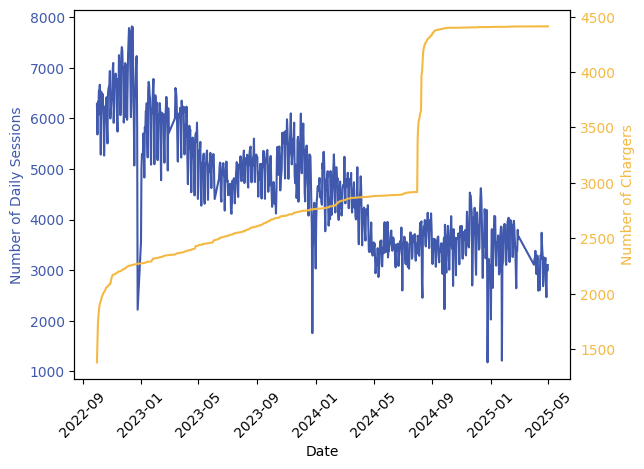

In [6]:

###################################PLOTTING####################################

#####plotting number of daily sessions and number of chargers observed

#grouping by start date and finding number of unique CPIDs as they appear on daily basis
unique_CPIDs_per_day = data.groupby('Start')['CPID'].apply(lambda x: x.unique()).reset_index()

#counting number of unique CPIDs as they appear in the dataset
cumulative_unique_ids_day = set()
cumulative_counts = []

for _, row in unique_CPIDs_per_day.iterrows():
    cumulative_unique_ids_day.update(row['CPID'])
    cumulative_counts.append({
        'Start': row['Start'],
        'Cumulative_Unique_CPID_Count_Day': len(cumulative_unique_ids_day)
    })

#converting cumulative counts to a dataframe
cumulative_counts_CPID = pd.DataFrame(cumulative_counts)

#finding the total number of sessions per day
sessions_per_day = data.groupby('Start').size().reset_index(name='session_count')

#merging to give a dataframe with the total number of sessions per day and the cumulative number of chargers observed
sessions_chargers = pd.merge(sessions_per_day, cumulative_counts_CPID, how='left', left_on='Start', right_on='Start')

#plotting
fig, ax1 = plt.subplots()

color = '#4059AD'
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of Daily Sessions', color = color)
plt.xticks(rotation=45)
ax1.plot(sessions_chargers.Start, sessions_chargers.session_count, color = color)
ax1.tick_params(axis ='y', labelcolor = color)

ax2 = ax1.twinx()

color = '#F4B942'
ax2.set_ylabel('Number of Chargers', color = color)
ax2.plot(sessions_chargers.Start, sessions_chargers.Cumulative_Unique_CPID_Count_Day, color = color)
ax2.tick_params(axis ='y', labelcolor = color)

plt.show()

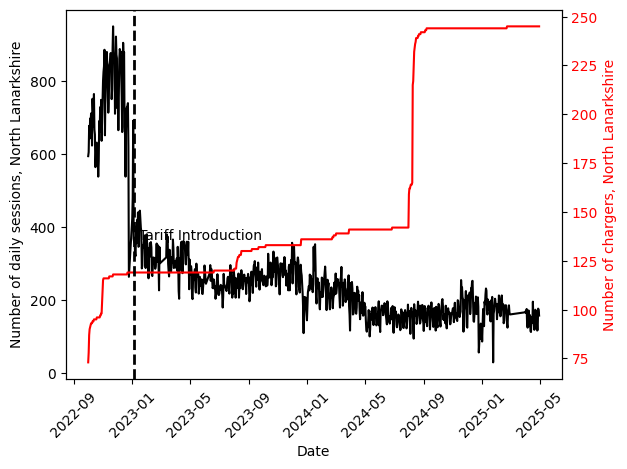

In [9]:
###############################################################################

#####North Lanarkshire sessions/sessions per charger
NorthLanarkshire = data[data['local_authority']=='North Lanarkshire'].copy()

sessions_per_day_nlan = NorthLanarkshire.groupby('Start').size().reset_index(name='session_count')

unique_CPIDs_per_day_nlan = NorthLanarkshire.groupby('Start')['CPID'].apply(lambda x: x.unique()).reset_index()

cumulative_unique_ids_day_nlan = set()
cumulative_counts_nlan = []

for _, row in unique_CPIDs_per_day_nlan.iterrows():
    cumulative_unique_ids_day_nlan.update(row['CPID'])
    cumulative_counts_nlan.append({
        'Start': row['Start'],
        'Cumulative_Unique_CPID_Count_Day_nlan': len(cumulative_unique_ids_day_nlan)
    })

cumulative_counts_nlan_df = pd.DataFrame(cumulative_counts_nlan)

merging_nlan = pd.merge(sessions_per_day_nlan, cumulative_counts_nlan_df, how='left', left_on='Start', right_on='Start')
merging_nlan['sessions_per_charger_day_nlan'] = merging_nlan['session_count'] / merging_nlan['Cumulative_Unique_CPID_Count_Day_nlan']

fig, ax1 = plt.subplots()
color = '#000000'
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of daily sessions, North Lanarkshire', color = color)
plt.xticks(rotation=45)
ax1.plot(merging_nlan.Start, merging_nlan.session_count, color = color)
ax1.tick_params(axis ='y', labelcolor = color)

ax2 = ax1.twinx()

color = '#FF0000'
ax2.set_ylabel('Number of chargers, North Lanarkshire', color = color)
ax2.plot(merging_nlan.Start, merging_nlan.Cumulative_Unique_CPID_Count_Day_nlan, color = color)
ax2.tick_params(axis ='y', labelcolor = color)

ax2.axvline(pd.to_datetime('2023-01-04'), color='black', linestyle='--', lw=2)
ax2.annotate('Tariff Introduction',xy=(pd.to_datetime('2023-01-15'), 136))

plt.show()

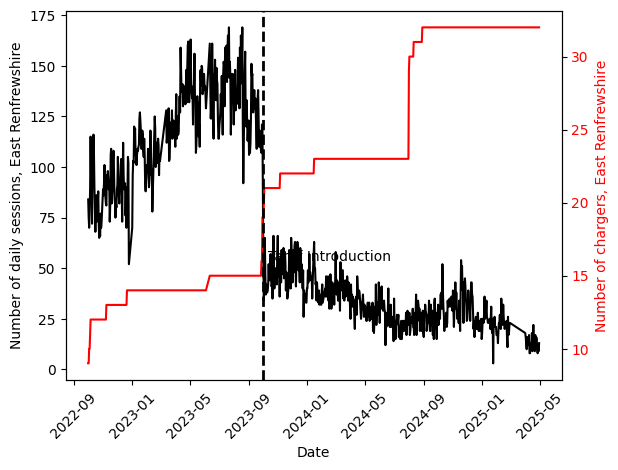

In [10]:
#####East Renfrewshire sessions/sessions per charger
EastRen = data[data['local_authority']=='East Renfrewshire'].copy()

sessions_per_day_EastRen = EastRen.groupby('Start').size().reset_index(name='session_count')

unique_CPIDs_per_day_EastRen = EastRen.groupby('Start')['CPID'].apply(lambda x: x.unique()).reset_index()

cumulative_unique_ids_day_EastRen = set()
cumulative_counts_EastRen = []

for _, row in unique_CPIDs_per_day_EastRen.iterrows():
    cumulative_unique_ids_day_EastRen.update(row['CPID'])
    cumulative_counts_EastRen.append({
        'Start': row['Start'],
        'Cumulative_Unique_CPID_Count_Day_EastRen': len(cumulative_unique_ids_day_EastRen)
    })

cumulative_counts_EastRen_df = pd.DataFrame(cumulative_counts_EastRen)

merging_EastRen = pd.merge(sessions_per_day_EastRen, cumulative_counts_EastRen_df, how='left', left_on='Start', right_on='Start')
merging_EastRen['sessions_per_charger_day_EastRen'] = merging_EastRen['session_count'] / merging_EastRen['Cumulative_Unique_CPID_Count_Day_EastRen']

#plotting number of sessions
fig, ax1 = plt.subplots()
color = '#000000'
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of daily sessions, East Renfrewshire', color = color)
plt.xticks(rotation=45)
ax1.plot(merging_EastRen.Start, merging_EastRen.session_count, color = color)
ax1.tick_params(axis ='y', labelcolor = color)

ax2 = ax1.twinx()

color = '#FF0000'
ax2.set_ylabel('Number of chargers, East Renfrewshire', color = color)
ax2.plot(merging_EastRen.Start, merging_EastRen.Cumulative_Unique_CPID_Count_Day_EastRen, color = color)
ax2.tick_params(axis ='y', labelcolor = color)

ax2.axvline(pd.to_datetime('2023-10-01'), color='black', linestyle='--', lw=2)
ax2.annotate('Tariff Introduction',xy=(pd.to_datetime('2023-10-12'), 16))

plt.show()

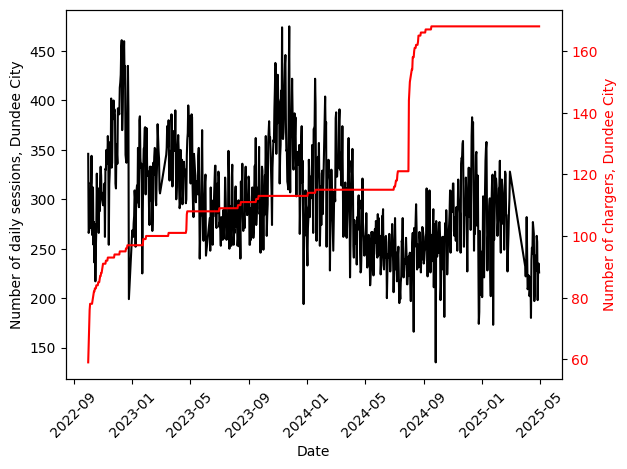

In [11]:

####Dundee City sessions/sessions per charger
DundeeCity = data[data['local_authority']=='Dundee City'].copy()

sessions_per_day_dundee = DundeeCity.groupby('Start').size().reset_index(name='session_count')

unique_CPIDs_per_day_dundee = DundeeCity.groupby('Start')['CPID'].apply(lambda x: x.unique()).reset_index()

cumulative_unique_ids_day_dundee = set()
cumulative_counts_dundee = []

for _, row in unique_CPIDs_per_day_dundee.iterrows():
    cumulative_unique_ids_day_dundee.update(row['CPID'])
    cumulative_counts_dundee.append({
        'Start': row['Start'],
        'Cumulative_Unique_CPID_Count_Day_dundee': len(cumulative_unique_ids_day_dundee)
    })

#converting the cumulative counts to a dataframe
cumulative_counts_dundee_df = pd.DataFrame(cumulative_counts_dundee)

merging_dundee = pd.merge(sessions_per_day_dundee, cumulative_counts_dundee_df, how='left', left_on='Start', right_on='Start')
merging_dundee['sessions_per_charger_day_dundee'] = merging_dundee['session_count'] / merging_dundee['Cumulative_Unique_CPID_Count_Day_dundee']

#plotting sessions per day
fig, ax1 = plt.subplots()
color = '#000000'
ax1.set_xlabel('Date')
ax1.set_ylabel('Number of daily sessions, Dundee City', color = color)
plt.xticks(rotation=45)
ax1.plot(merging_dundee.Start, merging_dundee.session_count, color = color)
ax1.tick_params(axis ='y', labelcolor = color)

ax2 = ax1.twinx()

color = '#FF0000'
ax2.set_ylabel('Number of chargers, Dundee City', color = color)
ax2.plot(merging_dundee.Start, merging_dundee.Cumulative_Unique_CPID_Count_Day_dundee, color = color)
ax2.tick_params(axis ='y', labelcolor = color)

plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24032\4267353412.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


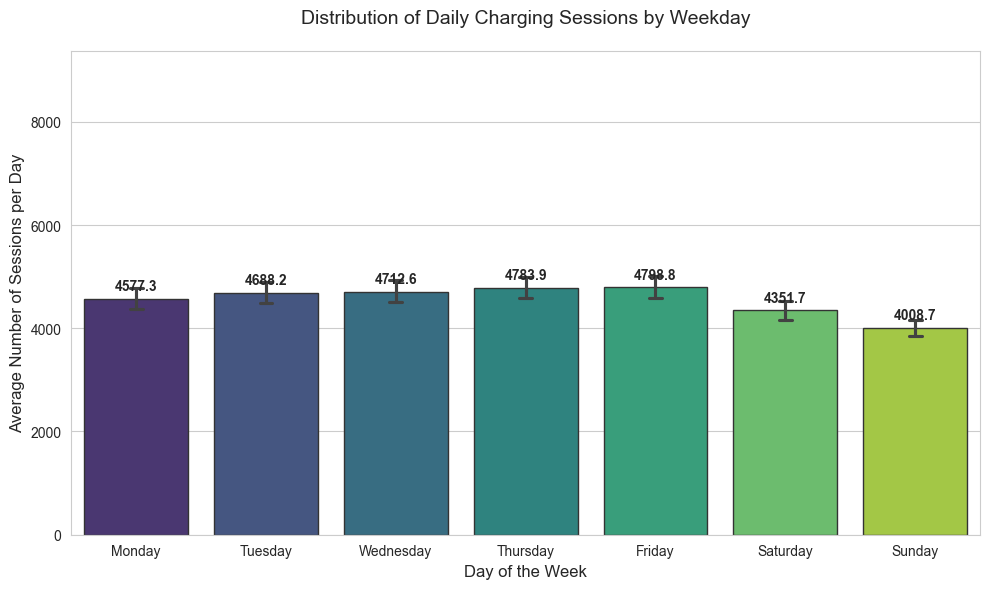

In [13]:
# Calculate the total number of sessions PER DAY (Date)
daily_summary = data.groupby(['Date', 'weekday']).size().reset_index(name='TotalSessions')

# Order the weekdays for proper plotting
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_summary['weekday'] = pd.Categorical(daily_summary['weekday'], categories=days_order, ordered=True)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")  

# Create the bar plot
# errorbar=('ci', 95) computes 95% confidence interval using bootstrapping
# capsize adds small horizontal lines at the ends of error bars
ax = sns.barplot(
    data=daily_summary, 
    x='weekday', 
    y='TotalSessions',
    palette='viridis', 
    errorbar=('ci', 95), 
    capsize=.1, 
    edgecolor='0.2'
)

# Add mean value labels on top of each bar for clarity
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.1f'),                   # Display value with 1 decimal
        (p.get_x() + p.get_width() / 2., p.get_height()), # Position on top center of bar
        ha='center', va='center',
        xytext=(0, 9),                                  # Offset label above bar
        textcoords='offset points',
        fontsize=10, fontweight='bold'
    )

# Customize the plot titles and axis labels
plt.title('Distribution of Daily Charging Sessions by Weekday', fontsize=14, pad=20)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Number of Sessions per Day', fontsize=12)

# Set y-axis limit to leave space for labels above bars
plt.ylim(0, daily_summary['TotalSessions'].max() * 1.2)

# Improve layout for tight spacing
plt.tight_layout()

# Save the figure as a vector PDF (suitable for publications)
plt.savefig('daily_sessions_distribution.pdf', format='pdf', bbox_inches='tight')

# Show the plot
plt.show()

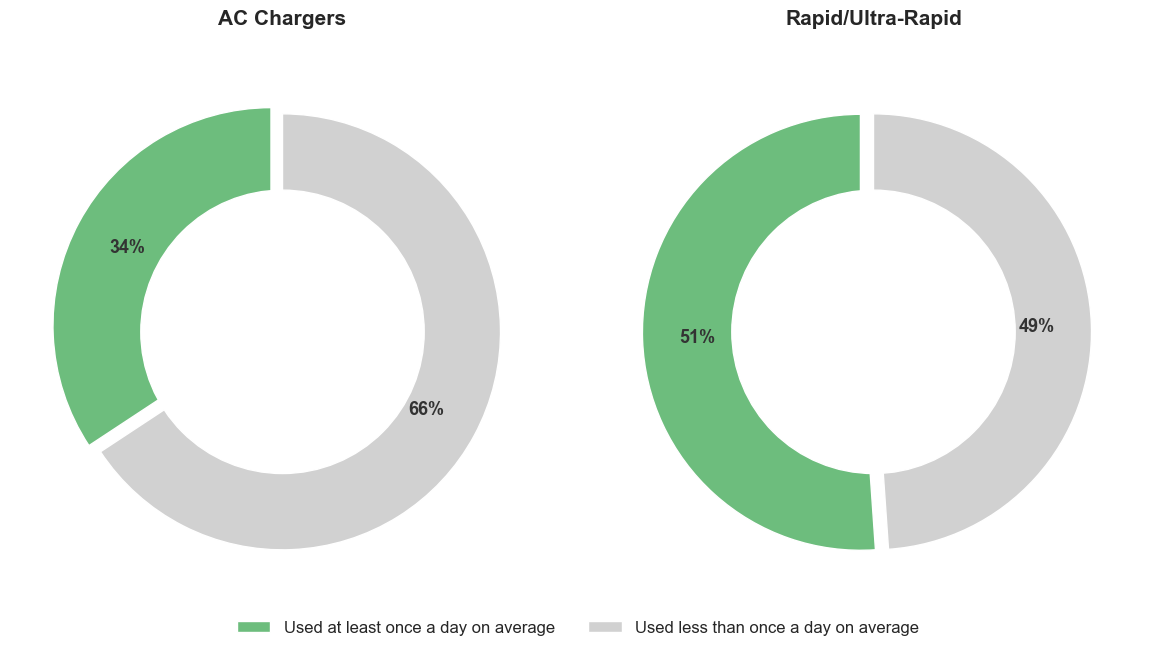

In [63]:

data['Date'] = pd.to_datetime(data['Date']).dt.date
all_days = data['Date'].unique()

def get_daily_activity_rate(connector_group):
    subset = data[data['Connector_Type'].isin(connector_group)]
    total_possible_active_days = subset['CPID'].nunique() * len(all_days)
    actual_active_days = subset.groupby(['Date', 'CPID']).size().shape[0]
    return (actual_active_days / total_possible_active_days) * 100

rate_ac = get_daily_activity_rate(['AC'])
rate_rapid = get_daily_activity_rate(['Rapid', 'Ultra-Rapid'])

COLOR_ACTIVE = '#6dbd7d'
COLOR_IDLE = '#d1d1d1'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))

def draw_donut(ax, percent, title, color_main):
    size = [percent, 100 - percent]
    colors = [color_main, COLOR_IDLE]

    wedges, texts, autotexts = ax.pie(
        size, labels=None, autopct='%1.0f%%', startangle=90,
        colors=colors, pctdistance=0.75, explode=(0.06, 0),
        textprops={'fontsize': 13, 'fontweight': 'bold', 'color': '#333333'}
    )

    centre_circle = plt.Circle((0,0), 0.65, fc='white')
    ax.add_artist(centre_circle)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=25)

    return wedges

patches = draw_donut(ax1, rate_ac, "AC Chargers", COLOR_ACTIVE)
draw_donut(ax2, rate_rapid, "Rapid/Ultra-Rapid", COLOR_ACTIVE)

fig.legend(
    [patches[0], patches[1]],
    ['Used at least once a day on average', 'Used less than once a day on average'],
    loc="lower center",
    fontsize=12,
    frameon=False,
    ncol=2,
    bbox_to_anchor=(0.5, 0.08)
)

plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.show()


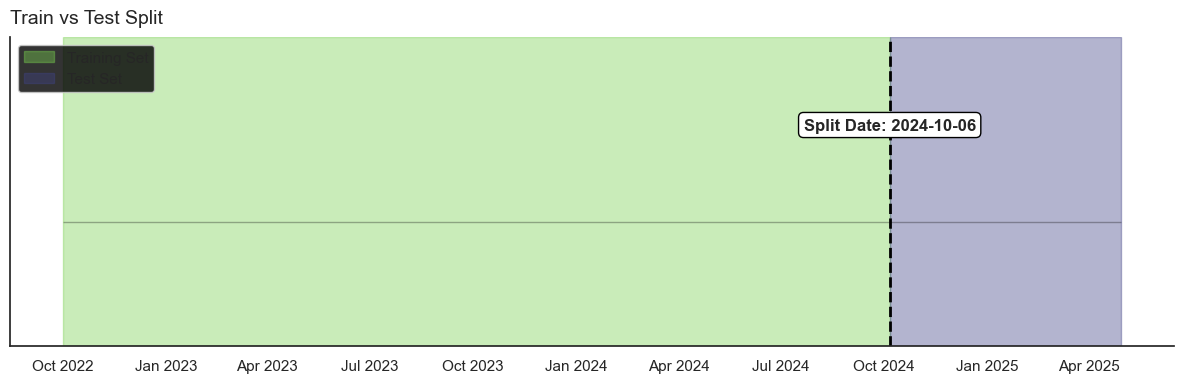

In [15]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm

df = data.copy()

# Exclude certain CPIDs
cpid_to_exclude = ["62201", "62202", "62203", "62266", "62261", "50433", "62123"]
df = df[~df['CPID'].isin(cpid_to_exclude)]

# Ensure 'Date' is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Filter dates up to April 30, 2025
cutoff_date = pd.to_datetime('2025-04-30')
df = df[df['Date'] <= cutoff_date].sort_values('Date')

# Unique sorted dates
unique_dates = sorted(df['Date'].unique())
split_idx = int(0.8 * len(unique_dates))
split_date = unique_dates[split_idx]

# Colors for training and test sets
color_train = cm.viridis(0.8)  # Yellow/green
color_test = cm.viridis(0.2)   # Purple/blue

# Plot
fig, ax = plt.subplots(figsize=(12, 4))

ax.axvspan(df['Date'].min(), split_date, color=color_train, alpha=0.4, label='Training Set')
ax.axvspan(split_date, df['Date'].max(), color=color_test, alpha=0.4, label='Test Set')

ax.hlines(y=1, xmin=df['Date'].min(), xmax=df['Date'].max(), color='black', linewidth=1, alpha=0.3)
ax.axvline(x=split_date, color='black', linestyle='--', linewidth=2)

ax.text(
    split_date, 1.15,
    f'Split Date: {split_date.strftime("%Y-%m-%d")}',
    ha='center', fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
)

ax.set_yticks([])
ax.set_ylim(0.8, 1.3)
ax.set_title("Train vs Test Split", loc='left', fontsize=14, pad=10)
ax.legend(loc='upper left')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()